# Ray tracing simulation # 

In [2]:
import os, importlib
import mitsuba as mi
print(mi.variants())

# mi.set_variant("llvm_ad_rgb")
mi.set_variant("llvm_ad_mono_polarized")

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, ITURadioMaterial

import sionna
from importlib.metadata import version
print("Sionna version:", version("sionna"))

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import util
import plot


['scalar_rgb', 'scalar_spectral', 'scalar_spectral_polarized', 'llvm_ad_rgb', 'llvm_ad_mono', 'llvm_ad_mono_polarized', 'llvm_ad_spectral', 'llvm_ad_spectral_polarized', 'cuda_ad_rgb', 'cuda_ad_mono', 'cuda_ad_mono_polarized', 'cuda_ad_spectral', 'cuda_ad_spectral_polarized']
Sionna version: 2.0.0


In [3]:
# Import scene as xml file
scene = load_scene("SimpleConfig/SimpleConfig.xml")

scene.radio_materials["itu-concrete"].thickness = 0.2

# print("Available materials:", scene.radio_materials.keys())
# mat = scene.radio_materials["itu-concrete"]
# print(f"Material: {mat.name}")
# print(f"Conductivity: {mat.conductivity.numpy()} S/m")
# print(f"Relative Permittivity: {mat.relative_permittivity.numpy()}")
# print(f"Thickness: {mat.thickness.numpy()} m")

ground = ITURadioMaterial("ground",
                        "concrete",
                        thickness=1,
                        color=[0.011, 0.27, 0.8])

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')

ground_object = scene.objects["elm__7"]
ground_object.radio_material = ground

scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')

scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='dipole',
                             polarization='V')

print(scene.rx_array.antenna_pattern.compute_gain())

tx = Transmitter("tx", [0, -2, 1.5])
# tx = Transmitter("tx", [-4, 8, 1])
scene.add(tx)

# Rx positions
x1, y1 = -7, 8
x2, y2 = 0, 8
x3, y3 = 7, 8
x4, y4 = 9, 0
x5, y5 = -9, 0
x6, y6 = -7, -8
x7, y7 = 0, -8
x8, y8 = 7, -8

RX_positions = [[x1, y1], [x2, y2], [x3, y3], [x4, y4], [x5, y5], [x6, y6], [x7, y7], [x8, y8]]

rx1 = Receiver("rx", [x1, y1, 1.5])
rx2 = Receiver("rx2", [x2, y2, 1.5])
rx3 = Receiver("rx3", [x3, y3, 1.5])
rx4 = Receiver("rx4", [x4, y4, 1.5])
rx5 = Receiver("rx5", [x5, y5, 1.5])
rx6 = Receiver("rx6", [x6, y6, 1.5])
rx7 = Receiver("rx7", [x7, y7, 1.5])
rx8 = Receiver("rx8", [x8, y8, 1.5])
scene.add(rx1)
scene.add(rx2)
scene.add(rx3)
scene.add(rx4)
scene.add(rx5)
scene.add(rx6)
scene.add(rx7)
scene.add(rx8)

scene.preview()

no-name-1      itu-concrete
elm__7         itu-glass
Directivity [dB]: 1.76
Gain [dB]: 1.76
Efficiency [%]: 1e+02
([1.49999], [1.5], [1.00001])


### Paths computations ###

In [4]:
pathSolver = PathSolver()
paths = pathSolver(scene=scene, max_depth=15)

# 1. Get current valid mask to know the correct shape
# This is crucial: 'valid' might have fewer dimensions than 'a'
original_valid_np = paths.valid.numpy()
target_shape = original_valid_np.shape

# 2. Get signal magnitude from 'a'
a_r, a_i = paths.a
a_r_np, a_i_np = a_r.numpy(), a_i.numpy()
magnitudes = np.sqrt(a_r_np**2 + a_i_np**2)

# 3. Reduce magnitude to match 'valid' shape
# If 'a' has extra antenna dimensions (dims 1 and 3), max over them
# Example: Convert [Rx, RxAnt, Tx, TxAnt, Paths] -> [Rx, Tx, Paths]
if len(magnitudes.shape) > len(target_shape):
    # Reduce dimensions 1 and 3 (antenna arrays) by taking the max power across antennas
    # Adjust axes based on your actual shape. Typically:
    # Axis 0=Rx, 1=RxAnt, 2=Tx, 3=TxAnt, 4=Paths
    reduced_magnitudes = np.max(magnitudes, axis=(1, 3)) 
else:
    reduced_magnitudes = magnitudes

# 4. Create the filter mask
# Keep paths where power is > 5% of peak
keep_mask = np.zeros(target_shape, dtype=bool)

# Iterate over Rx/Tx pairs to calculate local thresholds
for i in range(target_shape[0]): # Rx
    for j in range(target_shape[1]): # Tx
        # Get all paths for this link
        path_powers = reduced_magnitudes[i, j, :]
        max_val = np.max(path_powers)
        
        if max_val > 0:
            # Create boolean filter
            keep_mask[i, j, :] = path_powers >= (0.5 * max_val)

# 5. Combine with original validity (Logical AND)
# This ensures we don't accidentally "revive" non-existent paths
final_mask = keep_mask & original_valid_np

# 6. Apply to the internal _valid variable
# Use TensorXb (Extended Boolean Tensor)
paths._valid = mi.TensorXb(final_mask)

# 7. (Optional) Zero out 'a' for consistency
# You might need to broadcast the mask back to 'a's shape if they differ
paths._a = (
    mi.TensorXf(a_r_np * final_mask[:, None, :, None, :]), # Broadcast if needed
    mi.TensorXf(a_i_np * final_mask[:, None, :, None, :])
)


In [5]:
scene.preview(paths=paths)

0.001
1e-12


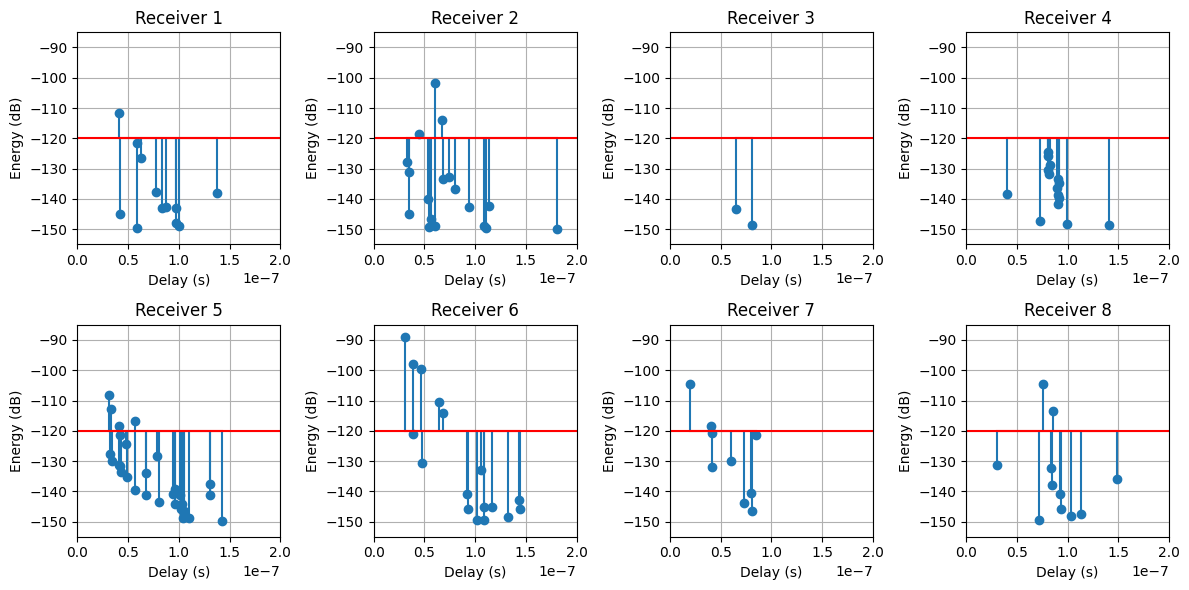

In [6]:
# Channel impulse response of the path
cir = paths.cir(sampling_frequency=3.5e9,
                num_time_steps=1,
                normalize_delays=False)

angles = paths.phi_r

a, tau, angles = util.format_paths(cir, angles)

# Energy of paths
magnitudes = [np.abs(a[i]) for i in range(8)]
energies = [magnitudes[i]**2 for i in range(8)]

# Power transmitted and receiver sensitivity
P_TX_dBm = 0
P_TX_lin = 10 ** (P_TX_dBm / 10) / 1000  # Convert dBm to Watts
print(P_TX_lin)

S_RX_dBm = -90
S_RX_lin = 10 ** (S_RX_dBm / 10) / 1000  # Convert dBm to Watts
print(S_RX_lin)

energies = [energies[i] * P_TX_lin for i in range(8)]


# Filter paths too weak
threshold = -150 # in dB, relative to P_TX
threshold_lin = 10 ** (threshold / 10)

for i in range(8):
    mask = energies[i] >= threshold_lin
    a[i] = a[i][mask]
    tau[i] = tau[i][mask]
    magnitudes[i] = magnitudes[i][mask]
    energies[i] = energies[i][mask]


plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.stem(tau[i], 10*np.log10(energies[i]), bottom=10*np.log10(S_RX_lin))
    plt.axhline(10*np.log10(S_RX_lin), color='red', linestyle='-', label='Sensitivity Threshold')
    plt.title(f"Receiver {i+1}")
    plt.xlabel("Delay (s)")
    plt.ylabel("Energy (dB)")
    plt.xlim(0, 2e-7)
    plt.ylim(-155, -85)
    plt.grid()
plt.tight_layout()

In [7]:
# ## System parameters ###

B = 100e6 # Bandwidth
oversampling_factor = 4
Fs = B * oversampling_factor # Sampling frequency (Nyquist rate)
Ts = 1 / Fs # Time step

N = 100 * oversampling_factor # Number of samples (adjusted for oversampling)
T = N * Ts
t = np.linspace(0, T, N, endpoint=False)
print(f"Time vector length: {len(t)} samples, Duration: {t[-1]} seconds")

Time vector length: 400 samples, Duration: 9.975e-07 seconds


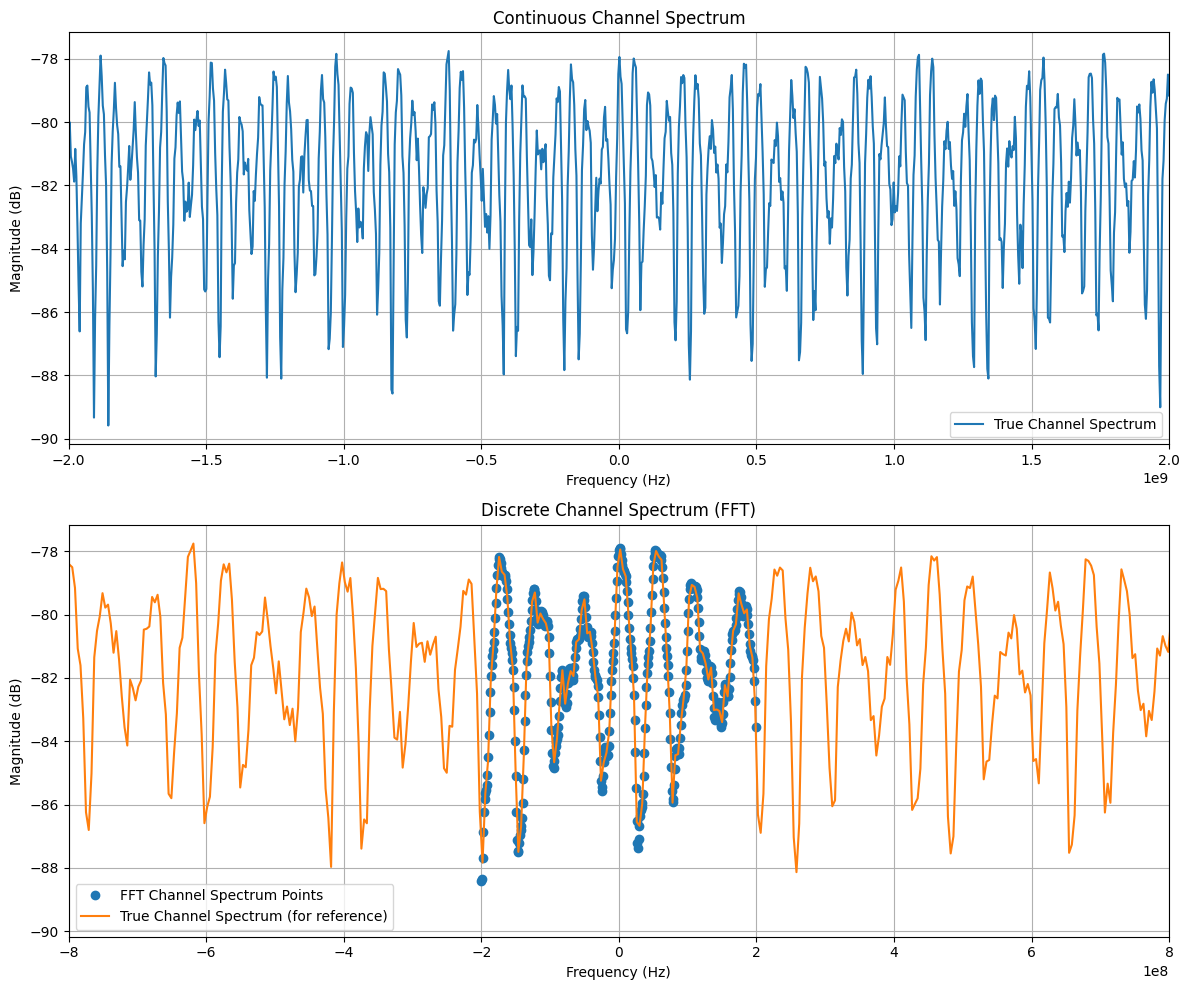

In [8]:
RX_idx = 0

# Frequency axis
f = np.fft.fftshift(np.fft.fftfreq(len(t), Ts))
f_continuous = np.linspace(-10*(Fs/2), 10*(Fs/2), 1000) # Extended frequency range for continuous spectrum

# True spectrum of the channel (continuous)
H_f = np.zeros(len(f_continuous), dtype=complex)
for i in range(len(a[RX_idx])):
    H_f += a[RX_idx][i] * np.exp(-1j * 2 * np.pi * f_continuous * tau[RX_idx][i])

# Discrete spectrum with FFT
H_fft = np.zeros(len(f), dtype=complex)
for i in range(len(a[RX_idx])):
    H_fft += a[RX_idx][i] * np.exp(-1j * 2 * np.pi * f * tau[RX_idx][i])
    
# Plotting
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Continuous spectrum
ax[0].plot(f_continuous, 20*np.log10(np.abs(H_f)), label='True Channel Spectrum')
ax[0].set_title("Continuous Channel Spectrum")
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Magnitude (dB)")
ax[0].set_xlim(-10*(Fs/2), 10*(Fs/2))

# Discrete spectrum
# ax[1].stem(f, 20*np.log10(np.abs(H_fft)), basefmt=" ", label='FFT Channel Spectrum', bottom=-83)
ax[1].plot(f, 20*np.log10(np.abs(H_fft)), 'o', label='FFT Channel Spectrum Points')
ax[1].plot(f_continuous, 20*np.log10(np.abs(H_f)), label='True Channel Spectrum (for reference)')
ax[1].set_title("Discrete Channel Spectrum (FFT)")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Magnitude (dB)")
ax[1].set_xlim(-4*(Fs/2), 4*(Fs/2))

for a_ in ax:
    a_.grid()
    a_.legend()

fig.tight_layout()
plt.show()


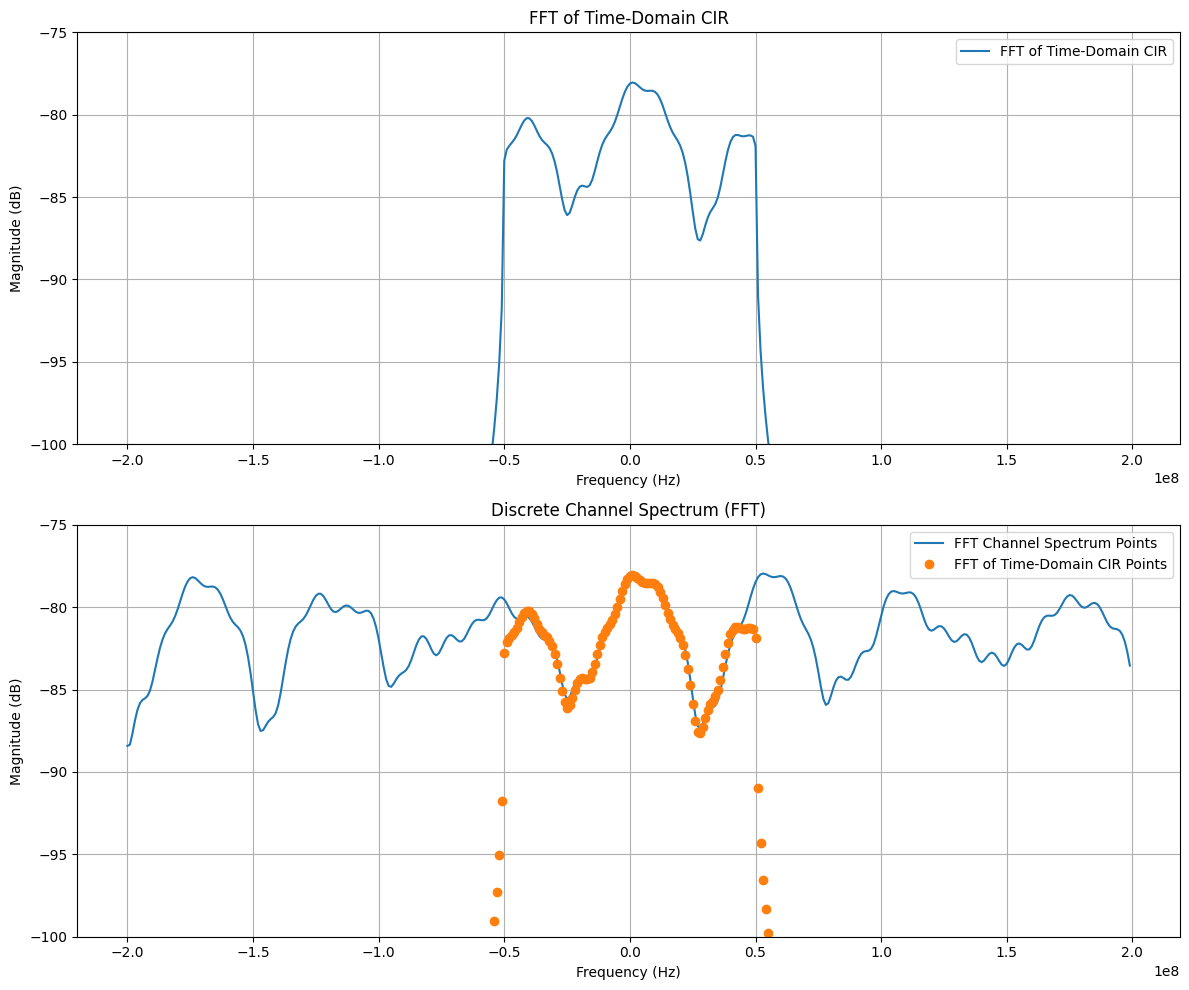

In [9]:
h_time = np.zeros(N, dtype=complex)
for i in range(len(a[RX_idx])):
    h_time += a[RX_idx][i] * 1/oversampling_factor * np.sinc((t - tau[RX_idx][i]) * B)

H_time_fft = np.fft.fft(h_time)
H_time_fft = np.fft.fftshift(H_time_fft)

fig, ax = plt.subplots(2, 1, figsize=(12, 10))
ax[0].plot(f, 20*np.log10(np.abs(H_time_fft)), label='FFT of Time-Domain CIR')
ax[0].set_title("FFT of Time-Domain CIR")
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Magnitude (dB)")

ax[1].plot(f, 20*np.log10(np.abs(H_fft)), '-', label='FFT Channel Spectrum Points')
ax[1].plot(f, 20*np.log10(np.abs(H_time_fft)), 'o', label='FFT of Time-Domain CIR Points')
ax[1].set_title("Discrete Channel Spectrum (FFT)")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Magnitude (dB)")

for a_ in ax:
    a_.set_ylim(-100, -75)
    a_.grid()
    a_.legend()

fig.tight_layout()
plt.show()

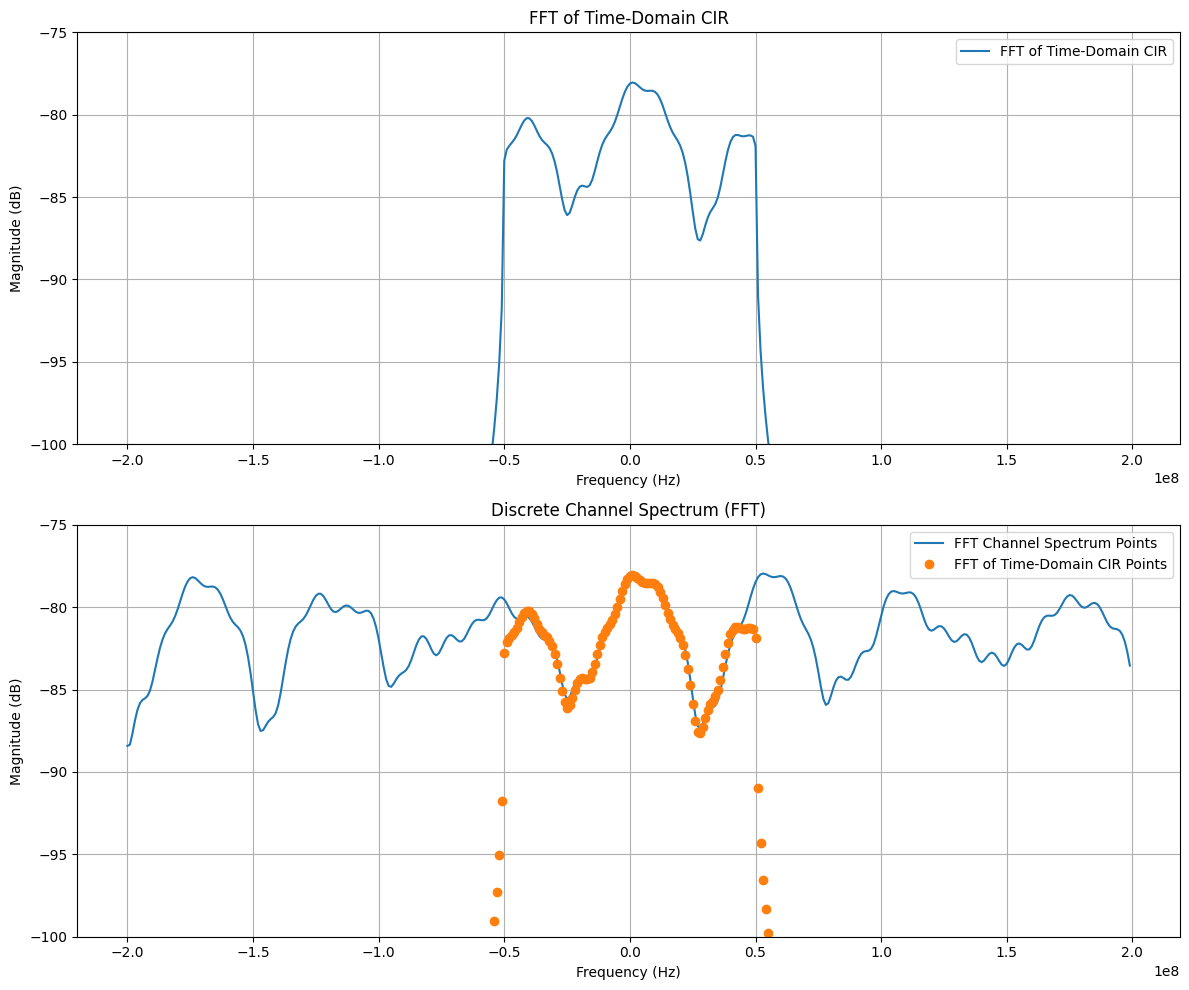

In [10]:
h_time = np.zeros(N, dtype=complex)
for i in range(len(a[RX_idx])):
    h_time += a[RX_idx][i] * 1/oversampling_factor * np.sinc((t - tau[RX_idx][i]) * B)

H_time_fft = np.fft.fft(h_time)
H_time_fft = np.fft.fftshift(H_time_fft)

fig, ax = plt.subplots(2, 1, figsize=(12, 10))
ax[0].plot(f, 20*np.log10(np.abs(H_time_fft)), label='FFT of Time-Domain CIR')
ax[0].set_title("FFT of Time-Domain CIR")
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Magnitude (dB)")

ax[1].plot(f, 20*np.log10(np.abs(H_fft)), '-', label='FFT Channel Spectrum Points')
ax[1].plot(f, 20*np.log10(np.abs(H_time_fft)), 'o', label='FFT of Time-Domain CIR Points')
ax[1].set_title("Discrete Channel Spectrum (FFT)")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Magnitude (dB)")

for a_ in ax:
    a_.set_ylim(-100, -75)
    a_.grid()
    a_.legend()

fig.tight_layout()
plt.show()

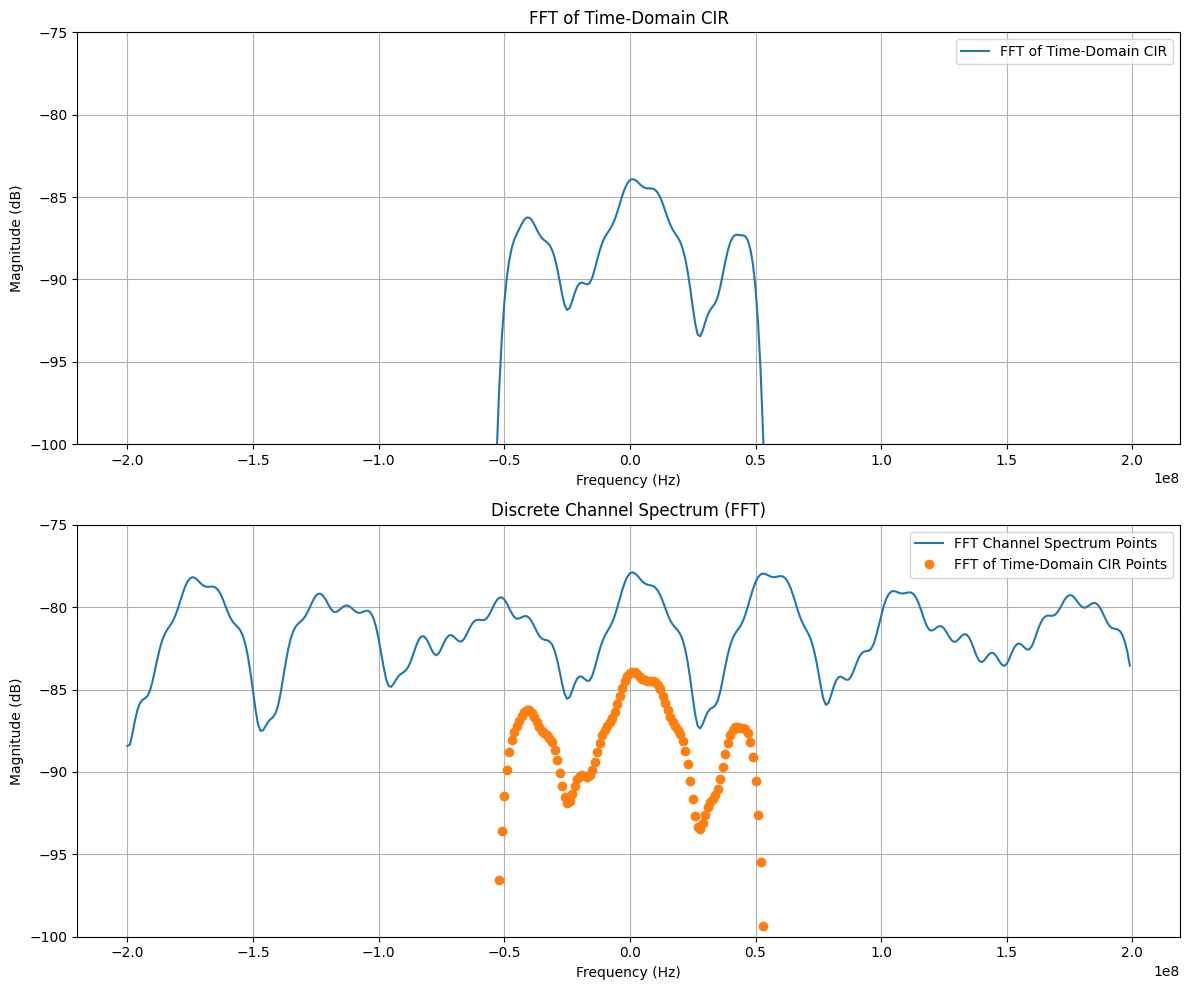

In [11]:
import Comm as com
importlib.reload(com)

h_time = np.zeros(N, dtype=complex)
for i in range(len(a[RX_idx])):
    h_time += a[RX_idx][i] * 1/oversampling_factor * com.RC(t, tau[RX_idx][i], B, alpha=0.1)

H_time_fft = np.fft.fft(h_time)
H_time_fft = np.fft.fftshift(H_time_fft)

fig, ax = plt.subplots(2, 1, figsize=(12, 10))
ax[0].plot(f, 20*np.log10(np.abs(H_time_fft)), label='FFT of Time-Domain CIR')
ax[0].set_title("FFT of Time-Domain CIR")
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Magnitude (dB)")

ax[1].plot(f, 20*np.log10(np.abs(H_fft)), '-', label='FFT Channel Spectrum Points')
ax[1].plot(f, 20*np.log10(np.abs(H_time_fft)), 'o', label='FFT of Time-Domain CIR Points')
ax[1].set_title("Discrete Channel Spectrum (FFT)")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Magnitude (dB)")

for a_ in ax:
    a_.set_ylim(-100, -75)
    a_.grid()
    a_.legend()

fig.tight_layout()
plt.show()

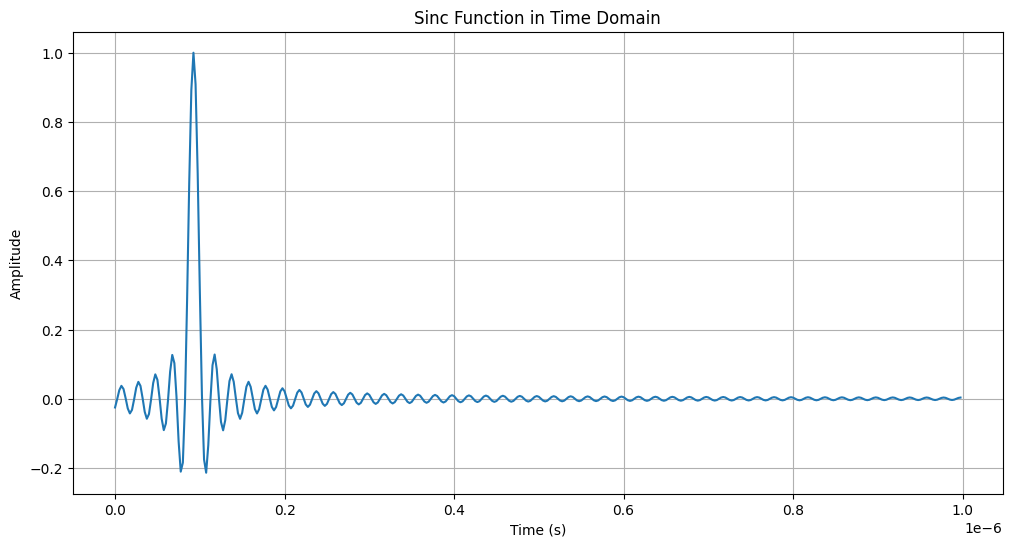

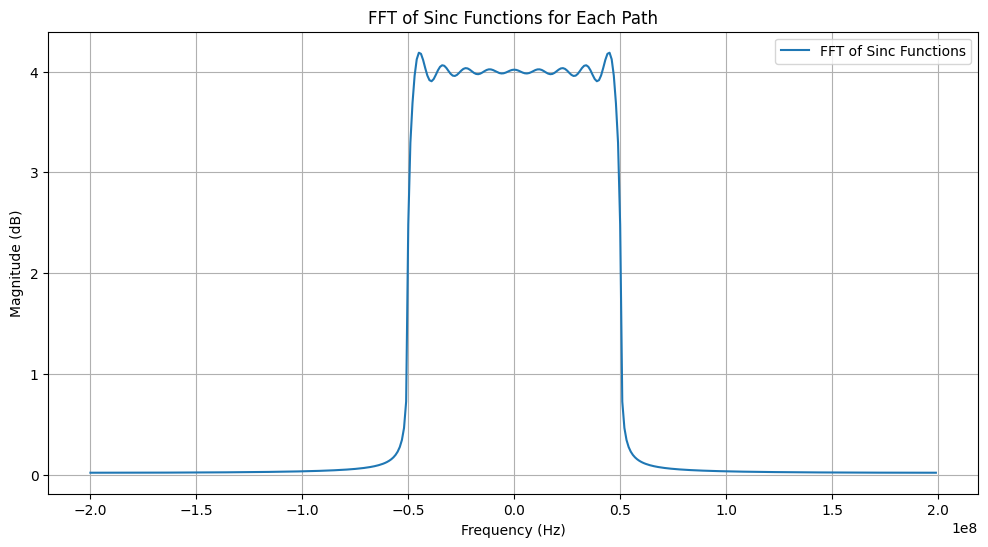

In [12]:
sinc = np.sinc((t + T/2.5 - T/2.03) * B)
fft_sinc = np.fft.fft(sinc, axis=0)
fft_sinc = np.fft.fftshift(fft_sinc, axes=0)

plt.figure(figsize=(12, 6))
plt.plot(t, sinc, label='Sinc Function (Time Domain)')
plt.title("Sinc Function in Time Domain")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()

plt.figure(figsize=(12, 6))
plt.plot(f, np.abs(fft_sinc), label='FFT of Sinc Functions')
plt.title("FFT of Sinc Functions for Each Path")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.legend()
plt.show()

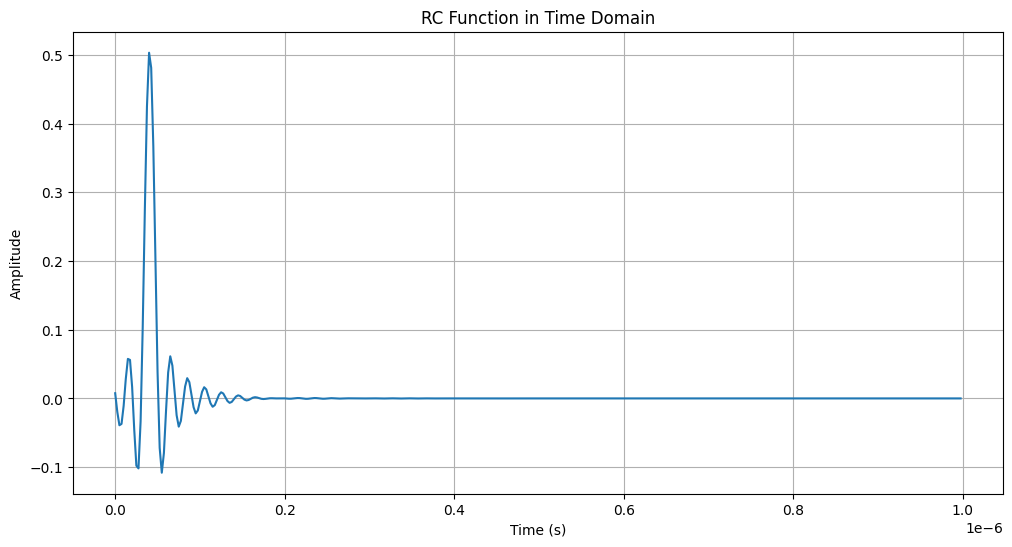

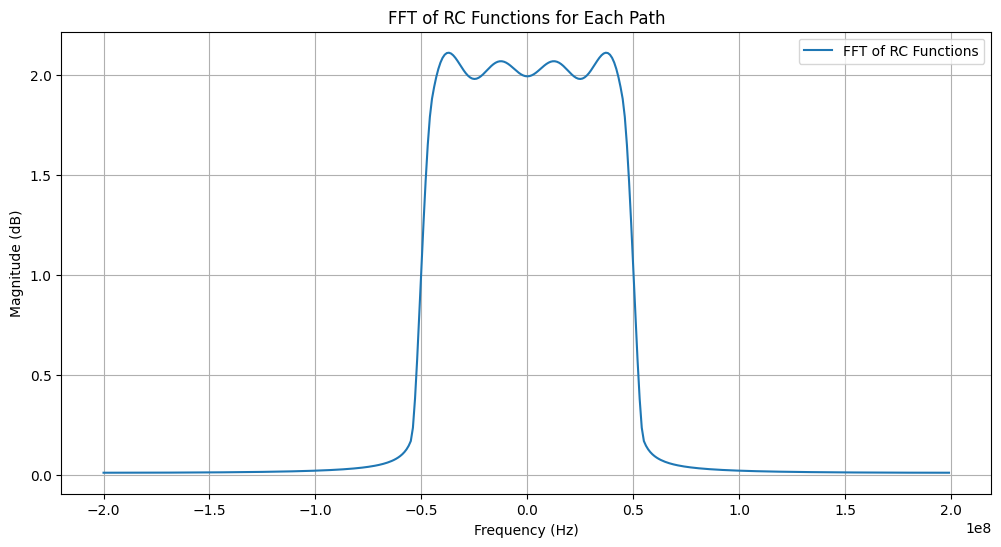

In [13]:
rc = com.RC(t, tau[RX_idx][0], B, alpha=0.1)
fft_rc = np.fft.fft(rc, axis=0)
fft_rc = np.fft.fftshift(fft_rc, axes=0)

plt.figure(figsize=(12, 6))
plt.plot(t, rc, label='RC Function (Time Domain)')
plt.title("RC Function in Time Domain")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()

plt.figure(figsize=(12, 6))
plt.plot(f, np.abs(fft_rc), label='FFT of RC Functions')
plt.title("FFT of RC Functions for Each Path")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.legend()
plt.show()

Noise power: 6.3023461249213765e-12
Filtered noise power: 7.709766834854255e-13


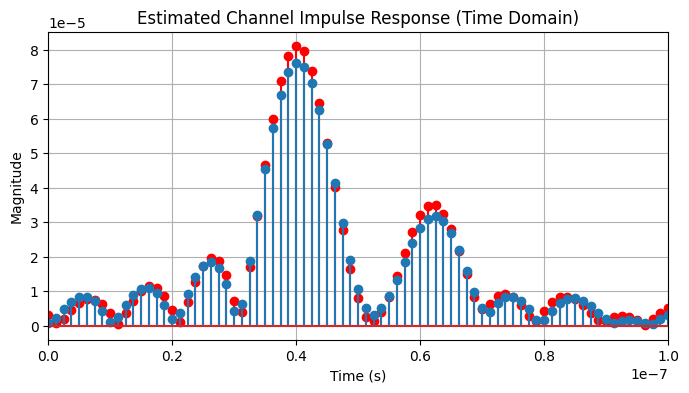

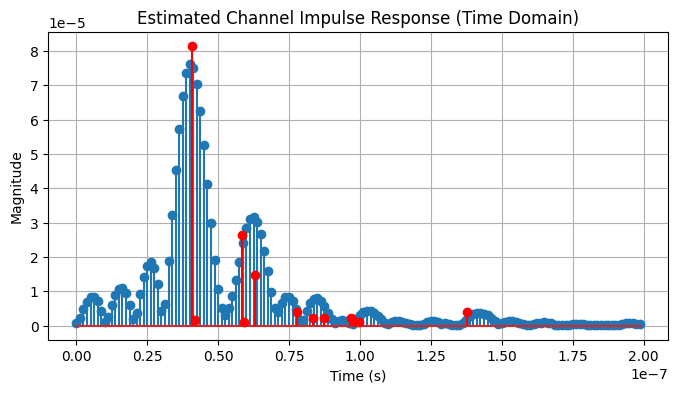

In [143]:
importlib.reload(com)

h_hat, t, h_time = com.get_sc_channel_response(a[RX_idx], tau[RX_idx], B, 8, T=2e-6, Tcir=2e-7, alpha=0.1)

plt.figure(figsize=(8, 4))
plt.stem(t, np.abs(h_time), label='Estimated CIR (Time Domain)', linefmt='r-', markerfmt='ro', basefmt=" ")
plt.stem(t[len(t)//2:len(t)//2 + len(h_hat)], np.abs(h_hat), label='Estimated CIR (Time Domain)')
plt.title("Estimated Channel Impulse Response (Time Domain)")
plt.xlabel("Time (s)")
plt.ylabel("Magnitude")
plt.xlim(0, 1e-7)
plt.grid()
plt.show()

plt.figure(figsize=(8, 4))
plt.stem(t[len(t)//2:len(t)//2 + len(h_hat)], np.abs(h_hat), label='Estimated CIR (Time Domain)')
plt.stem(tau[RX_idx], np.abs(a[RX_idx]), linefmt='r-', markerfmt='ro', basefmt=" ", label='True Path Amplitudes')
plt.title("Estimated Channel Impulse Response (Time Domain)")
plt.xlabel("Time (s)")
plt.ylabel("Magnitude")
plt.grid()
plt.show()

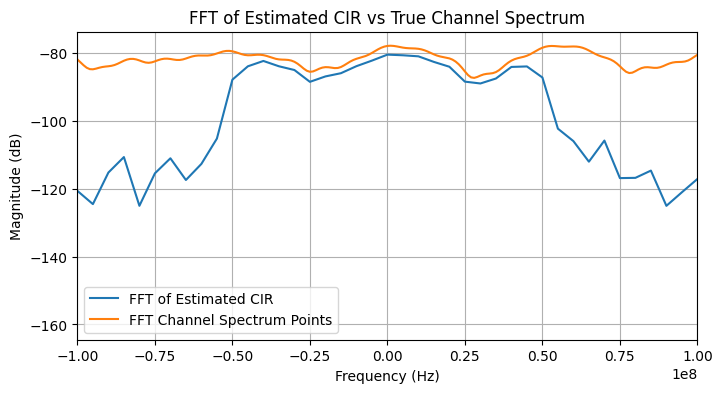

In [147]:
h_hat_fft = np.fft.fft(h_hat, axis=0)
h_hat_fft = np.fft.fftshift(h_hat_fft, axes=0)
f_hat = np.fft.fftshift(np.fft.fftfreq(len(h_hat), 1/(B*8)))

plt.figure(figsize=(8, 4))
plt.plot(f_hat, 20*np.log10(np.abs(h_hat_fft))-20, label='FFT of Estimated CIR')
plt.plot(f, 20*np.log10(np.abs(H_fft)), label='FFT Channel Spectrum Points')
plt.title("FFT of Estimated CIR vs True Channel Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.xlim(-1e8, 1e8)
plt.grid()
plt.legend()
plt.show()

Noise power: 6.272372082951061e-12
Filtered noise power: 7.803997372895305e-13


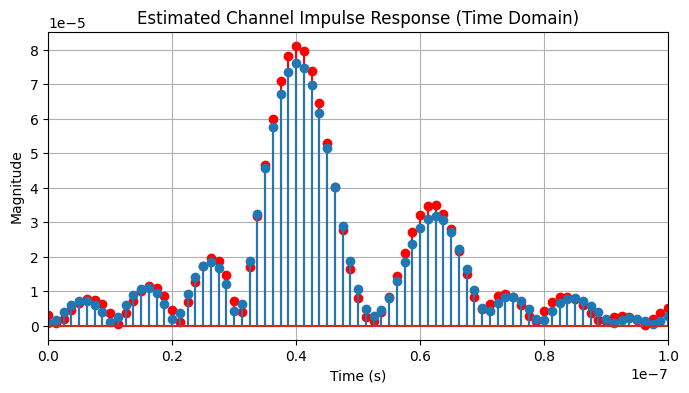

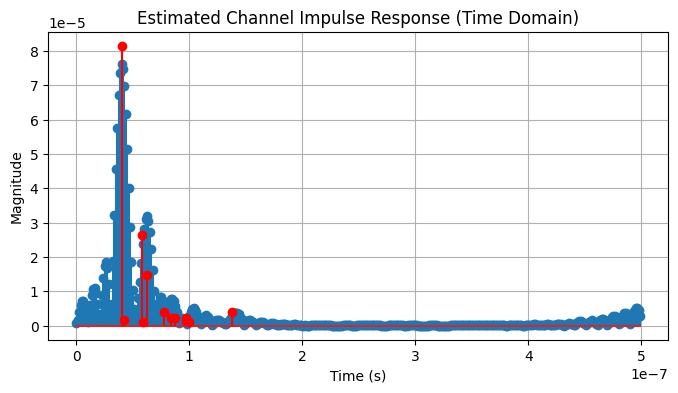

In [141]:
importlib.reload(com)

h_hat, t, h_time = com.get_sc_cp_channel_response(a[RX_idx], tau[RX_idx], B, 8, T=2e-6, Tcir=2e-7, alpha=0.1)

plt.figure(figsize=(8, 4))
plt.stem(t, np.abs(h_time), label='Estimated CIR (Time Domain)', linefmt='r-', markerfmt='ro', basefmt=" ")
plt.stem(t[len(t)//2:len(t)//2 + len(h_hat)], np.abs(h_hat), label='Estimated CIR (Time Domain)')
plt.title("Estimated Channel Impulse Response (Time Domain)")
plt.xlabel("Time (s)")
plt.ylabel("Magnitude")
plt.xlim(0, 1e-7)
plt.grid()
plt.show()

plt.figure(figsize=(8, 4))
plt.stem(t[len(t)//2:len(t)//2 + len(h_hat)], np.abs(h_hat), label='Estimated CIR (Time Domain)')
plt.stem(tau[RX_idx], np.abs(a[RX_idx]), linefmt='r-', markerfmt='ro', basefmt=" ", label='True Path Amplitudes')
plt.title("Estimated Channel Impulse Response (Time Domain)")
plt.xlabel("Time (s)")
plt.ylabel("Magnitude")
plt.grid()
plt.show()

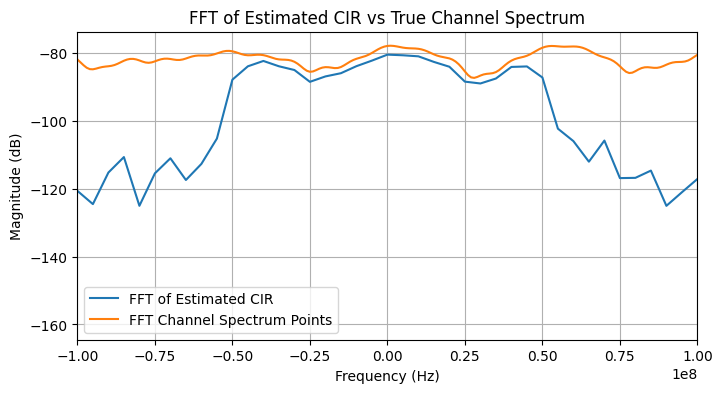

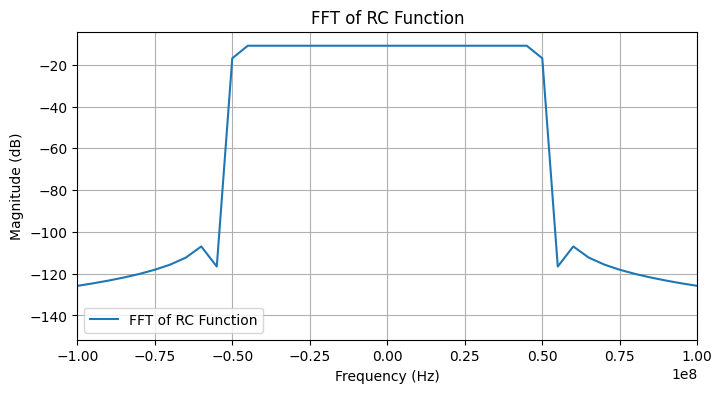

In [151]:
h_hat_fft = np.fft.fft(h_hat, axis=0)
h_hat_fft = np.fft.fftshift(h_hat_fft, axes=0)
f_hat = np.fft.fftshift(np.fft.fftfreq(len(h_hat), 1/(B*8)))

plt.figure(figsize=(8, 4))
plt.plot(f_hat, 20*np.log10(np.abs(h_hat_fft))-20, label='FFT of Estimated CIR')
plt.plot(f, 20*np.log10(np.abs(H_fft)), label='FFT Channel Spectrum Points')
plt.title("FFT of Estimated CIR vs True Channel Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.xlim(-1e8, 1e8)
plt.grid()
plt.legend()
plt.show()

rc_fft = np.fft.fft(com.RC(t, 0, B, alpha=0.1), axis=0)[::10]
rc_fft = np.fft.fftshift(rc_fft, axes=0)
f_rc = np.fft.fftshift(np.fft.fftfreq(len(t), 1/(B*8)))[::10]
plt.figure(figsize=(8, 4))
plt.plot(f_rc, 20*np.log10(np.abs(rc_fft))-20, label='FFT of RC Function')
plt.title("FFT of RC Function")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.xlim(-1e8, 1e8)
plt.grid()
plt.legend()
plt.show()

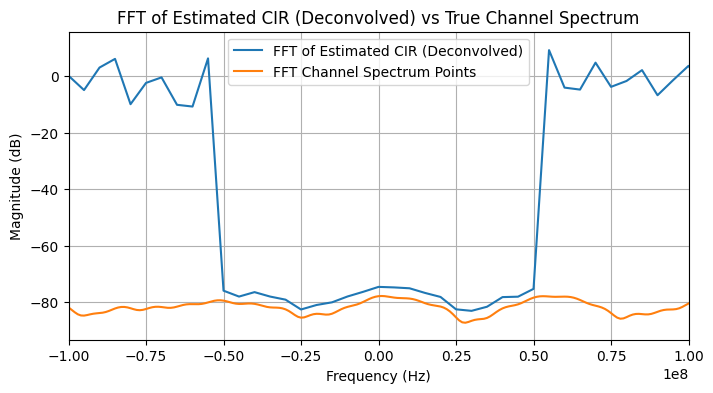

In [154]:
real_h_hat_fft = h_hat_fft / rc_fft
plt.figure(figsize=(8, 4))
plt.plot(f_hat, 20*np.log10(np.abs(real_h_hat_fft))-5, label='FFT of Estimated CIR (Deconvolved)')
plt.plot(f, 20*np.log10(np.abs(H_fft)), label='FFT Channel Spectrum Points')
plt.title("FFT of Estimated CIR (Deconvolved) vs True Channel Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.xlim(-1e8, 1e8)
plt.grid()
plt.legend()
plt.show()